<a href="https://colab.research.google.com/github/J9832323/Traffic-Congestion/blob/main/Traffic_Volume.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.set_printoptions(precision=3, suppress=True)
import pandas as pd
import sklearn
sklearn.set_config(print_changed_only=True)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import scale, StandardScaler
from sklearn.datasets import fetch_openml
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import make_pipeline as make_imb_pipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
# 5  basic different model
# at least 1 fine tuning
# compare with scaling
# box plot

In [ ]:
# Try Fine tuning

In [ ]:
traffic = pd.read_csv('TrafficVolumeData.csv', header=  0)

In [ ]:
traffic

,date_time,is_holiday,air_pollution_index,humidity,wind_speed,wind_direction,visibility_in_miles,dew_point,temperature,rain_p_h,snow_p_h,clouds_all,weather_type,weather_description,traffic_volume
0,2012-10-02 09:00:00,NaN,121,89,2,329,1,1,288.28,0.0,0.0,40,Clouds,scattered clouds,5545
1,2012-10-02 10:00:00,NaN,178,67,3,330,1,1,289.36,0.0,0.0,75,Clouds,broken clouds,4516
2,2012-10-02 11:00:00,NaN,113,66,3,329,2,2,289.58,0.0,0.0,90,Clouds,overcast clouds,4767
3,2012-10-02 12:00:00,NaN,20,66,3,329,5,5,290.13,0.0,0.0,90,Clouds,overcast clouds,5026
4,2012-10-02 13:00:00,NaN,281,65,3,329,7,7,291.14,0.0,0.0,75,Clouds,broken clouds,4918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33745,2017-05-17 21:00:00,NaN,74,85,1,328,7,7,287.88,0.0,0.0,90,Mist,mist,2348
33746,2017-05-17 22:00:00,NaN,81,70,1,24,2,2,286.95,0.0,0.0,90,Rain,heavy intensity rain,2194
33747,2017-05-17 22:00:00,NaN,138,70,1,24,1,1,286.95,0.0,0.0,90,Mist,mist,2194
33748,2017-05-17 23:00:00,NaN,229,66,1,42,6,6,285.75,0.0,0.0,90,Rain,heavy intensity rain,1328


In [ ]:
traffic.dtypes

,0
date_time,object
is_holiday,object
air_pollution_index,int64
humidity,int64
wind_speed,int64
wind_direction,int64
visibility_in_miles,int64
dew_point,int64
temperature,float64
rain_p_h,float64


In [ ]:
# Create dummy variables for categorical features
traffic = pd.get_dummies(traffic, columns=['is_holiday', 'weather_type', 'weather_description'], dtype='int64')
traffic.dtypes

,0
date_time,object
air_pollution_index,int64
humidity,int64
wind_speed,int64
wind_direction,int64
...,...
weather_description_thunderstorm with heavy rain,int64
weather_description_thunderstorm with light drizzle,int64
weather_description_thunderstorm with light rain,int64
weather_description_thunderstorm with rain,int64


In [ ]:
# Convert 'date_time' column to datetime objects
traffic['date_time'] = pd.to_datetime(traffic['date_time'])

# Convert datetime objects to Unix timestamps (seconds since epoch)
traffic['date_time'] = traffic['date_time'].astype('int64') // 10**9


In [ ]:
# Enter code here to drop the observations which has missing variables
traffic = traffic.replace(' ', np.nan)
traffic = traffic.dropna()

# If you want to see the data again
traffic

,date_time,air_pollution_index,humidity,wind_speed,wind_direction,visibility_in_miles,dew_point,temperature,rain_p_h,snow_p_h,...,weather_description_sleet,weather_description_smoke,weather_description_snow,weather_description_thunderstorm,weather_description_thunderstorm with drizzle,weather_description_thunderstorm with heavy rain,weather_description_thunderstorm with light drizzle,weather_description_thunderstorm with light rain,weather_description_thunderstorm with rain,weather_description_very heavy rain
0,1349168400,121,89,2,329,1,1,288.28,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,1349172000,178,67,3,330,1,1,289.36,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,1349175600,113,66,3,329,2,2,289.58,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,1349179200,20,66,3,329,5,5,290.13,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,1349182800,281,65,3,329,7,7,291.14,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33745,1495054800,74,85,1,328,7,7,287.88,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
33746,1495058400,81,70,1,24,2,2,286.95,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
33747,1495058400,138,70,1,24,1,1,286.95,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
33748,1495062000,229,66,1,42,6,6,285.75,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Decision Tree Classisifer


In [ ]:
# Define features (X) and target variable (y)
X = traffic.drop('traffic_volume', axis=1)
y = traffic['traffic_volume']

# Define traffic volume categories (High, Low)


def categorize_traffic(volume):
    if volume >= 4000:
        return 'High'
    else:
        return 'Low'

y_categorized = y.apply(categorize_traffic)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_categorized, test_size=0.25)


# Initialize and train the Decision Tree Classifier
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

        High       0.65      0.64      0.64      3670
         Low       0.73      0.73      0.73      4768

    accuracy                           0.69      8438
   macro avg       0.69      0.68      0.69      8438
weighted avg       0.69      0.69      0.69      8438

[[2352 1318]
 [1292 3476]]


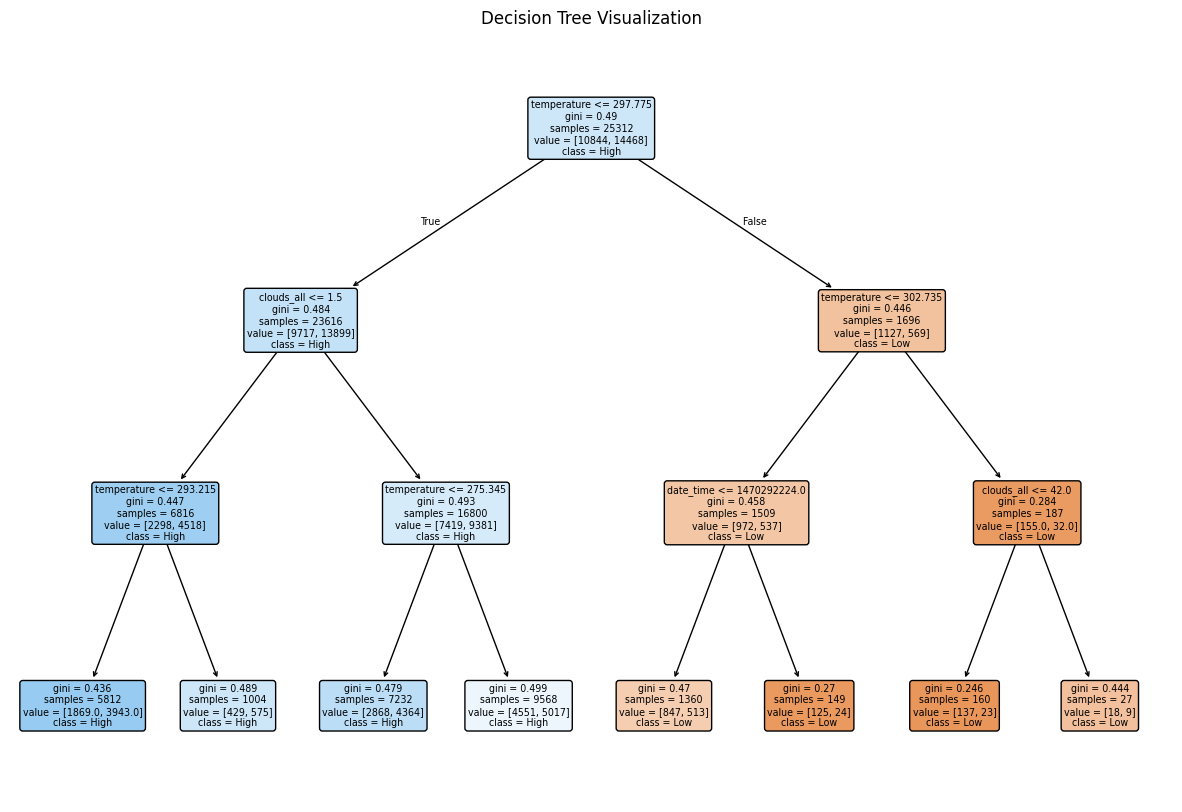

In [ ]:
from sklearn.tree import plot_tree
clf = DecisionTreeClassifier(max_depth=3)  # Limit depth to 3
clf.fit(X_train, y_train)

plt.figure(figsize=(15,10))
plot_tree(clf, feature_names=X.columns, class_names=['Low', 'High'], filled=True, rounded=True)
plt.title('Decision Tree Visualization')
plt.show()

In [ ]:
y_categorized.value_counts()

,count
traffic_volume,
Low,19205
High,14545


In [ ]:
# Random Forest Classifier


In [ ]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

X = traffic.drop('traffic_volume', axis=1)
y = traffic['traffic_volume']

# Recategorize the target variable for RandomForest
y_categorized = y.apply(categorize_traffic)

X_train, X_test, y_train, y_test = train_test_split(X, y_categorized, test_size=0.25)

rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)

rfc_pred = rfc.predict(X_test)

print(classification_report(y_test, rfc_pred))
print('\n')
print(confusion_matrix(y_test, rfc_pred))


              precision    recall  f1-score   support

        High       0.64      0.50      0.56      3664
         Low       0.67      0.79      0.73      4774

    accuracy                           0.66      8438
   macro avg       0.66      0.64      0.64      8438
weighted avg       0.66      0.66      0.65      8438



[[1817 1847]
 [1003 3771]]


In [ ]:
# K-Nearest Neighbors (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# K-Nearest Neighbors (KNN)
X = traffic.drop('traffic_volume', axis=1)
y = traffic['traffic_volume']

# Recategorize the target variable for KNN
y_categorized = y.apply(categorize_traffic)

X_train, X_test, y_train, y_test = train_test_split(X, y_categorized, test_size = 0.25)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print(classification_report(y_test, knn_pred))
print('\n')
print(confusion_matrix(y_test, knn_pred))


              precision    recall  f1-score   support

        High       0.88      0.88      0.88      3565
         Low       0.91      0.91      0.91      4873

    accuracy                           0.90      8438
   macro avg       0.89      0.89      0.89      8438
weighted avg       0.90      0.90      0.90      8438



[[3137  428]
 [ 440 4433]]


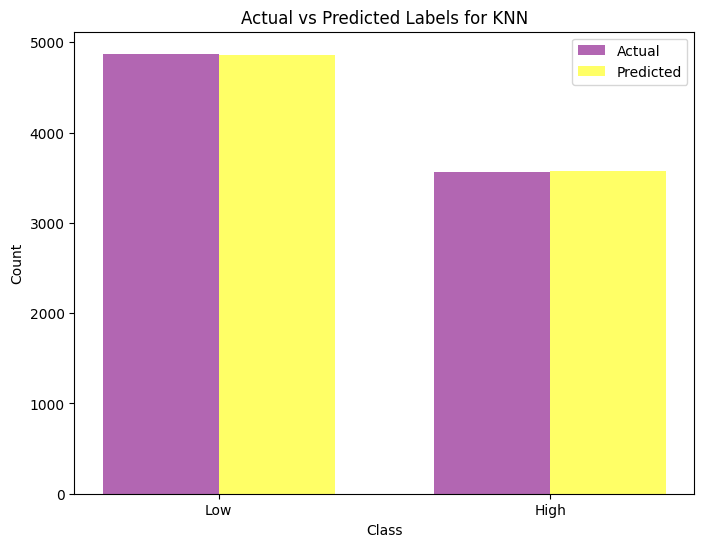

In [ ]:
predicted_counts = y_test.value_counts()
predicted_pred_counts = pd.Series(knn_pred).value_counts()

# Plot actual vs predicted bar chart
labels = ['Low', 'High']
x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(8, 6))


# Actual labels
plt.bar(x - width/2,predicted_counts[labels] ,width , alpha=0.6, label='Actual', color='purple')

# Predicted labels
plt.bar(x + width/2,predicted_pred_counts[labels],width, alpha=0.6, label='Predicted', color='yellow')

# Add title and labels
plt.xticks(x, labels)
plt.title('Actual vs Predicted Labels for KNN')
plt.xlabel('Class')
plt.ylabel('Count')

# Add legend
plt.legend()

# Show plot
plt.show()


In [ ]:
# Logic Regression

In [ ]:
# Logistic Regression

X = traffic.drop('traffic_volume', axis=1)
y = traffic['traffic_volume']

# Recategorize the target variable for Logistic Regression
y_categorized = y.apply(categorize_traffic)

X_train, X_test, y_train, y_test = train_test_split(X, y_categorized, test_size=0.25)

logreg = LogisticRegression(max_iter=1000) # Increased max_iter
logreg.fit(X_train, y_train)

logreg_pred = logreg.predict(X_test)

print(classification_report(y_test, logreg_pred))
print('\n')
print(confusion_matrix(y_test, logreg_pred))


              precision    recall  f1-score   support

        High       0.00      0.00      0.00      3651
         Low       0.57      1.00      0.72      4787

    accuracy                           0.57      8438
   macro avg       0.28      0.50      0.36      8438
weighted avg       0.32      0.57      0.41      8438



[[   0 3651]
 [   0 4787]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#SVM

In [ ]:
# prompt: run a Support Vector Machines (SVM) for traffic df Classification the traffic_volume as High, Med or Low

from sklearn.svm import SVC

# SVM
X = traffic.drop('traffic_volume', axis=1)
y = traffic['traffic_volume']

# Recategorize the target variable for SVM
y_categorized = y.apply(categorize_traffic)

X_train, X_test, y_train, y_test = train_test_split(X, y_categorized, test_size=0.25, random_state=42)

svm = SVC(kernel='linear') # You can experiment with different kernels (e.g., 'rbf', 'poly')
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print(classification_report(y_test, svm_pred))
print('\n')
print(confusion_matrix(y_test, svm_pred))


In [ ]:
from sklearn.svm import LinearSVC

In [ ]:
# (SVM)

from sklearn.svm import SVC

# SVM
X = traffic.drop('traffic_volume', axis=1)
y = traffic['traffic_volume']

# Recategorize the target variable for SVM
y_categorized = y.apply(categorize_traffic)

X_train, X_test, y_train, y_test = train_test_split(X, y_categorized, test_size=0.25, random_state=42)

svm = LinearSVC(max_iter=1000) #
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print(classification_report(y_test, svm_pred))
print('\n')
print(confusion_matrix(y_test, svm_pred))

              precision    recall  f1-score   support

        High       0.00      0.00      0.00      3664
         Low       0.57      1.00      0.72      4774

    accuracy                           0.57      8438
   macro avg       0.28      0.50      0.36      8438
weighted avg       0.32      0.57      0.41      8438



[[   0 3664]
 [   0 4774]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


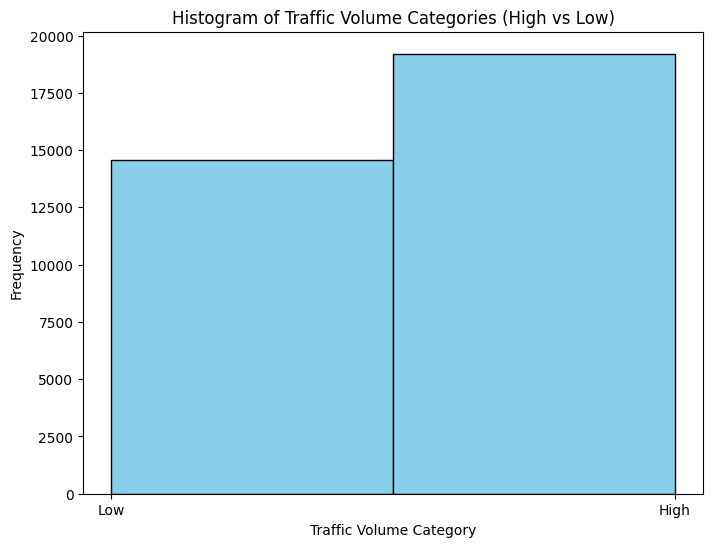

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

plt.figure(figsize=(8, 6))

# Plotting histogram
plt.hist(y_categorized, bins=2, edgecolor='black', color='skyblue')

# Adding titles and labels
plt.title('Histogram of Traffic Volume Categories (High vs Low)')
plt.xlabel('Traffic Volume Category')
plt.ylabel('Frequency')

# Set x-ticks to reflect High and Low
plt.xticks([0, 1], ['Low', 'High'])

# Show the plot
plt.show()

In [ ]:
# With Scaling

In [ ]:
# Decision Tree Classisifer With Scaling

In [ ]:

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the Decision Tree Classifier with scaled data
clf_scaled = DecisionTreeClassifier()
clf_scaled.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_scaled = clf_scaled.predict(X_test_scaled)

# Evaluate the model with scaled data
print("Decision Tree Classifier with Scaling:")
print(classification_report(y_test, y_pred_scaled))
print(confusion_matrix(y_test, y_pred_scaled))


Decision Tree Classifier with Scaling:
              precision    recall  f1-score   support

        High       0.64      0.64      0.64      3651
         Low       0.73      0.73      0.73      4787

    accuracy                           0.69      8438
   macro avg       0.68      0.68      0.68      8438
weighted avg       0.69      0.69      0.69      8438

[[2335 1316]
 [1311 3476]]


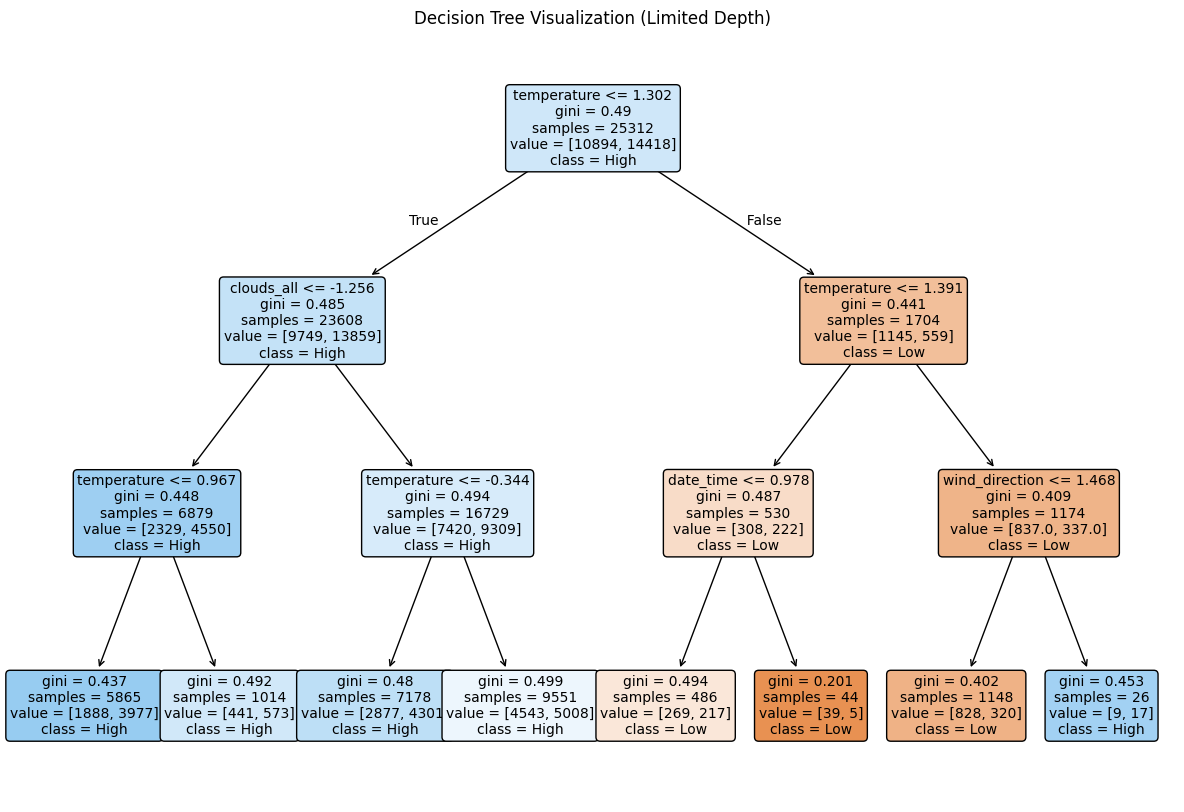

In [ ]:
# Initialize and train the Decision Tree Classifier with scaled data
clf_scaled = DecisionTreeClassifier(max_depth=3)  # Limit the depth of the tree
clf_scaled.fit(X_train_scaled, y_train)


# Plot the Decision Tree
plt.figure(figsize=(15, 10))  # Set the figure size
plot_tree(clf_scaled,
          feature_names=X.columns,  # Feature names for the X data
          class_names=['Low', 'High'],  # The target variable classes
          filled=True,  # Color the nodes based on the class
          rounded=True,  # Round the corners for a nice look
          fontsize=10)  # Font size for better visibility
plt.title('Decision Tree Visualization (Limited Depth)')
plt.show()

In [ ]:
#  Random Forest Classifier With Scaling

In [ ]:
#  Random Forest Classifier With Scaling

# Random Forest Classifier With Scaling

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train a Random Forest Classifier with scaled data
rfc_scaled = RandomForestClassifier()
rfc_scaled.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
rfc_pred_scaled = rfc_scaled.predict(X_test_scaled)

# Evaluate the model with scaled data
print("Random Forest Classifier with Scaling:")
print(classification_report(y_test, rfc_pred_scaled))
print(confusion_matrix(y_test, rfc_pred_scaled))


Random Forest Classifier with Scaling:
              precision    recall  f1-score   support

        High       0.64      0.49      0.56      3651
         Low       0.67      0.79      0.73      4787

    accuracy                           0.66      8438
   macro avg       0.66      0.64      0.64      8438
weighted avg       0.66      0.66      0.65      8438

[[1802 1849]
 [1007 3780]]


In [ ]:
# K-Nearest Neighbors (KNN)

In [ ]:

# K-Nearest Neighbors (KNN) with Scaling

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train a KNN classifier with scaled data
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
knn_pred_scaled = knn_scaled.predict(X_test_scaled)

# Evaluate the model with scaled data
print("K-Nearest Neighbors (KNN) with Scaling:")
print(classification_report(y_test, knn_pred_scaled))
print(confusion_matrix(y_test, knn_pred_scaled))


K-Nearest Neighbors (KNN) with Scaling:
              precision    recall  f1-score   support

        High       0.50      0.44      0.47      3651
         Low       0.61      0.67      0.64      4787

    accuracy                           0.57      8438
   macro avg       0.56      0.55      0.55      8438
weighted avg       0.56      0.57      0.56      8438

[[1612 2039]
 [1602 3185]]


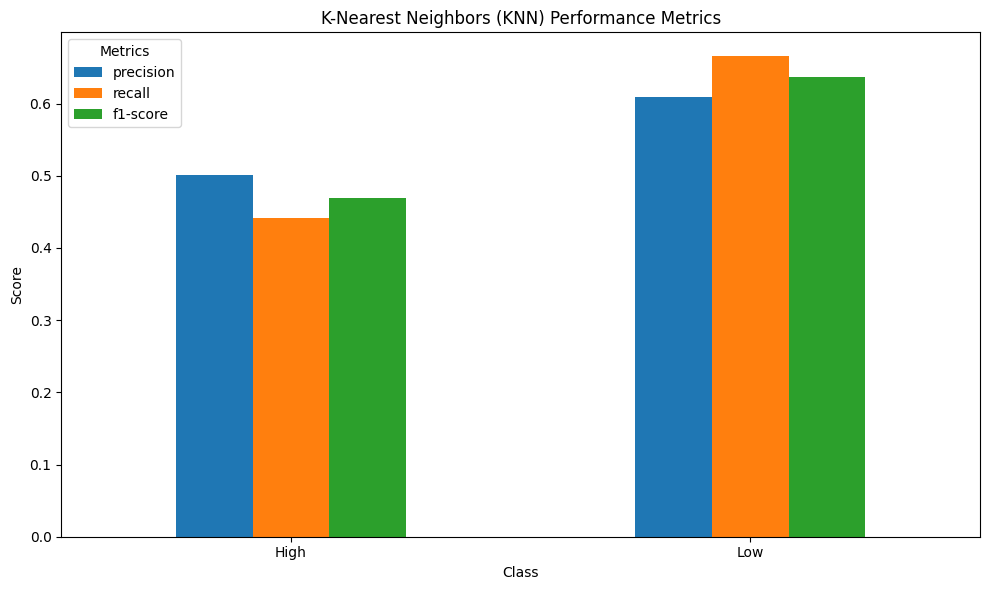

In [ ]:
report = classification_report(y_test, knn_pred_scaled, output_dict=True)

# Create a DataFrame to organize the metrics
metrics_df = pd.DataFrame(report).transpose()

# Plot a bar chart for Precision, Recall, and F1-Score
metrics_to_plot = ['precision', 'recall', 'f1-score']
metrics_df = metrics_df.loc[['High', 'Low'], metrics_to_plot]

# Plotting
metrics_df.plot(kind='bar', figsize=(10, 6))
plt.title('K-Nearest Neighbors (KNN) Performance Metrics')
plt.xlabel('Class')
plt.ylabel('Score')
plt.xticks(rotation=0)  # Keep the class labels horizontal
plt.legend(title='Metrics')
plt.tight_layout()  # Adjust layout for better presentation
plt.show()

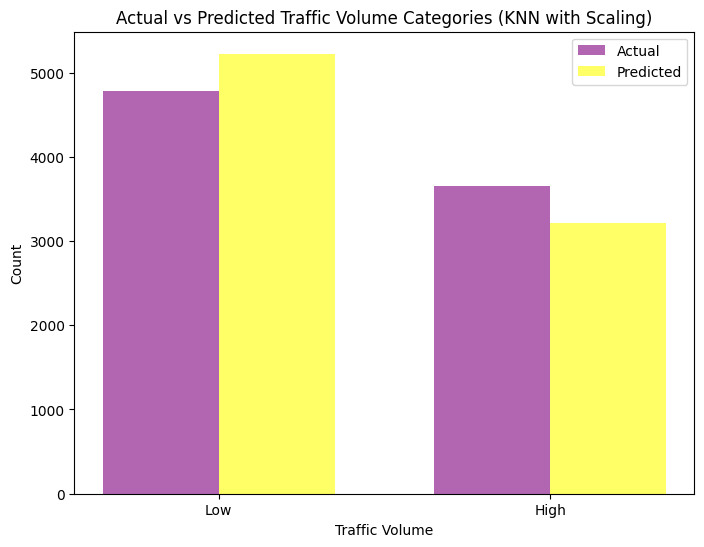

In [ ]:
#Just another KNN model
actual_counts = y_test.value_counts()
predicted_counts = pd.Series(knn_pred_scaled).value_counts()

# Ensure both counts have 'Low' and 'High' (fill missing categories with 0)
actual_counts = actual_counts.reindex(['Low', 'High'])
predicted_counts = predicted_counts.reindex(['Low', 'High'])

# Plot the Actual vs Predicted counts for scaled data
labels = ['Low', 'High']
x = np.arange(len(labels))  # positions for 'Low' and 'High'
width = 0.35  # bar width

plt.figure(figsize=(8, 6))

# Actual counts
plt.bar(x - width/2, actual_counts[labels], width, alpha=0.6, label='Actual', color='purple')

# Predicted counts
plt.bar(x + width/2, predicted_counts[labels], width, alpha=0.6, label='Predicted', color='yellow')

# Formatting the plot
plt.xticks(x, labels)
plt.title('Actual vs Predicted Traffic Volume Categories (KNN with Scaling)')
plt.xlabel('Traffic Volume')
plt.ylabel('Count')
plt.legend()

# Show plot
plt.show()

In [ ]:
# Logic Regression

In [ ]:
# Logistic Regression with Scaling

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train a Logistic Regression classifier with scaled data
logreg_scaled = LogisticRegression(max_iter=1000)
logreg_scaled.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
logreg_pred_scaled = logreg_scaled.predict(X_test_scaled)

# Evaluate the model with scaled data
print("Logistic Regression with Scaling:")
print(classification_report(y_test, logreg_pred_scaled))
print(confusion_matrix(y_test, logreg_pred_scaled))


Logistic Regression with Scaling:
              precision    recall  f1-score   support

        High       0.54      0.27      0.36      3651
         Low       0.60      0.83      0.69      4787

    accuracy                           0.58      8438
   macro avg       0.57      0.55      0.52      8438
weighted avg       0.57      0.58      0.55      8438

[[ 971 2680]
 [ 826 3961]]


In [ ]:
#SVM

In [ ]:
#SVM with Scaling

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train an SVM classifier with scaled data
svm_scaled = linear # You can experiment with different kernels (e.g., 'rbf', 'poly')
svm_scaled.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
svm_pred_scaled = svm_scaled.predict(X_test_scaled)

# Evaluate the model with scaled data
print("SVM with Scaling:")
print(classification_report(y_test, svm_pred_scaled))
print(confusion_matrix(y_test, svm_pred_scaled))


In [ ]:

#SVM with Scaling

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train an SVM classifier with scaled data
svm_scaled = LinearSVC(max_iter=10000) # You can experiment with different kernels (e.g., 'rbf', 'poly')
svm_scaled.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
svm_pred_scaled = svm_scaled.predict(X_test_scaled)

# Evaluate the model with scaled data
print("SVM with Scaling:")
print(classification_report(y_test, svm_pred_scaled))
print(confusion_matrix(y_test, svm_pred_scaled))

SVM with Scaling:
              precision    recall  f1-score   support

        High       0.56      0.27      0.36      3664
         Low       0.60      0.84      0.70      4774

    accuracy                           0.59      8438
   macro avg       0.58      0.55      0.53      8438
weighted avg       0.58      0.59      0.55      8438

[[ 985 2679]
 [ 787 3987]]


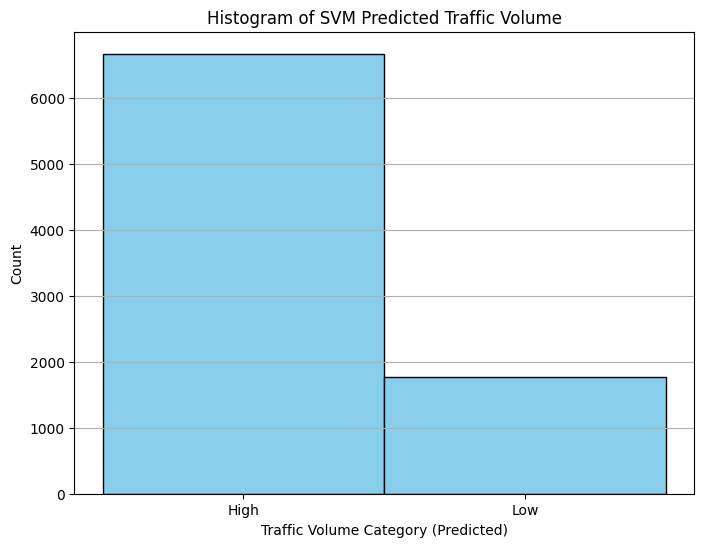

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(svm_pred_scaled, bins=np.arange(len(np.unique(svm_pred_scaled)) + 1) - 0.5, edgecolor='black', color='skyblue')
plt.xticks(np.arange(len(np.unique(svm_pred_scaled))), np.unique(svm_pred_scaled))
plt.xlabel('Traffic Volume Category (Predicted)')
plt.ylabel('Count')
plt.title('Histogram of SVM Predicted Traffic Volume')
plt.grid(axis='y')
plt.show()

In [ ]:
# With Fine Tuning

In [ ]:
# K-Nearest Neighbors (KNN)

In [ ]:

# K-Nearest Neighbors (KNN) with Fine Tuning

# Fine-tune KNN by finding the optimal n_neighbors
from sklearn.model_selection import GridSearchCV

X = traffic.drop('traffic_volume', axis=1)
y = traffic['traffic_volume']
y_categorized = y.apply(categorize_traffic)
X_train, X_test, y_train, y_test = train_test_split(X, y_categorized, test_size=0.25)

knn_tuned = KNeighborsClassifier()
param_grid = {'n_neighbors': np.arange(1, 25)} # Explore a range of neighbors
knn_gscv = GridSearchCV(knn_tuned, param_grid, cv=5) # 5-fold cross-validation
knn_gscv.fit(X_train, y_train)

best_knn = knn_gscv.best_estimator_
print(f"Best n_neighbors: {knn_gscv.best_params_['n_neighbors']}")

knn_tuned_pred = best_knn.predict(X_test)

print(classification_report(y_test, knn_tuned_pred))
print('\n')
print(confusion_matrix(y_test, knn_tuned_pred))


Best n_neighbors: 1
              precision    recall  f1-score   support

        High       0.92      0.91      0.92      3618
         Low       0.93      0.94      0.94      4820

    accuracy                           0.93      8438
   macro avg       0.93      0.93      0.93      8438
weighted avg       0.93      0.93      0.93      8438



[[3301  317]
 [ 292 4528]]


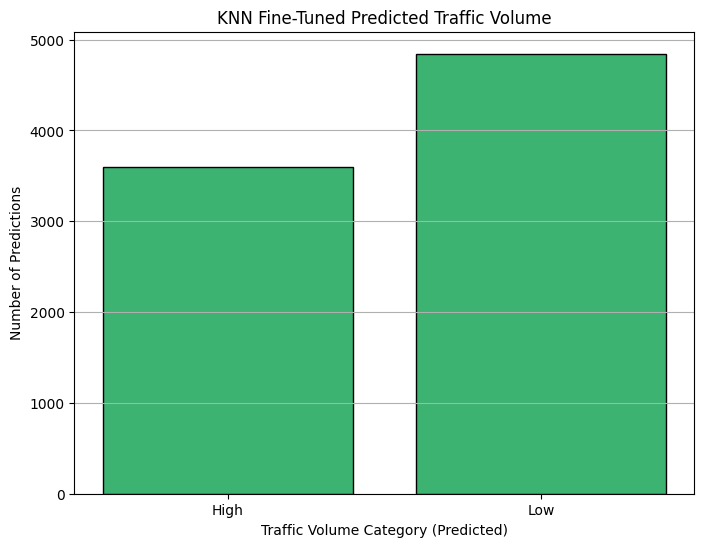

In [ ]:
unique, counts = np.unique(knn_tuned_pred, return_counts=True)

# Create the bar chart
plt.figure(figsize=(8, 6))
plt.bar(unique, counts, color='mediumseagreen', edgecolor='black')
plt.xlabel('Traffic Volume Category (Predicted)')
plt.ylabel('Number of Predictions')
plt.title('KNN Fine-Tuned Predicted Traffic Volume')
plt.grid(axis='y')
plt.show()

In [ ]:
#SVM

In [ ]:
#
from sklearn.model_selection import GridSearchCV
# Define the parameter grid for SVM
param_grid = {'C': [ 1, 10 ],
              'kernel': ['rbf']}

# Create a GridSearchCV object
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3,n_jobs=- 1)

# Fit the grid search to the data
grid.fit(X_train, y_train)

# Print the best parameters and best score
print(grid.best_params_)
print(grid.best_estimator_)

# Make predictions using the best model
grid_predictions = grid.predict(X_test)

# Evaluate the model
print(classification_report(y_test, grid_predictions))
print('\n')
print(confusion_matrix(y_test, grid_predictions))


Fitting 5 folds for each of 2 candidates, totalling 10 fits
{'C': 1, 'kernel': 'rbf'}
SVC(C=1)
              precision    recall  f1-score   support

        High       0.00      0.00      0.00      3622
         Low       0.57      1.00      0.73      4816

    accuracy                           0.57      8438
   macro avg       0.29      0.50      0.36      8438
weighted avg       0.33      0.57      0.41      8438



[[   0 3622]
 [   0 4816]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:

X = traffic.drop('traffic_volume', axis=1)
y = traffic['traffic_volume']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

predictions = dtree.predict(X_test)

print(classification_report(y_test,predictions))
print('\n')
print(confusion_matrix(y_test,predictions))


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.00      0.00      0.00         4
           2       0.50      0.50      0.50         2
           3       0.00      0.00      0.00         2
           5       0.50      0.33      0.40         3
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         1
          10       0.50      1.00      0.67         1
          11       0.00      0.00      0.00         0
          24       0.50      1.00      0.67         1
          44       0.00      0.00      0.00         0
          64       0.00      0.00      0.00         1
          97       0.00      0.00      0.00         1
         108       0.00      0.00      0.00         0
         113       1.00      1.00      1.00         1
         123       0.00      0.00      0.00         0
         149       0.00    

In [ ]:
y_train.value_counts()

,count
traffic_volume,
Low,14413
High,10899


In [ ]:
rfc_pred = rfc.predict(X_train)

print(classification_report(y_train, rfc_pred))
print('\n')
print(confusion_matrix(y_train, rfc_pred))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00     10871
         Low       1.00      1.00      1.00     14441

    accuracy                           1.00     25312
   macro avg       1.00      1.00      1.00     25312
weighted avg       1.00      1.00      1.00     25312



[[10871     0]
 [    0 14441]]


Text(0.5, 1.0, 'Correlation Heatmap')

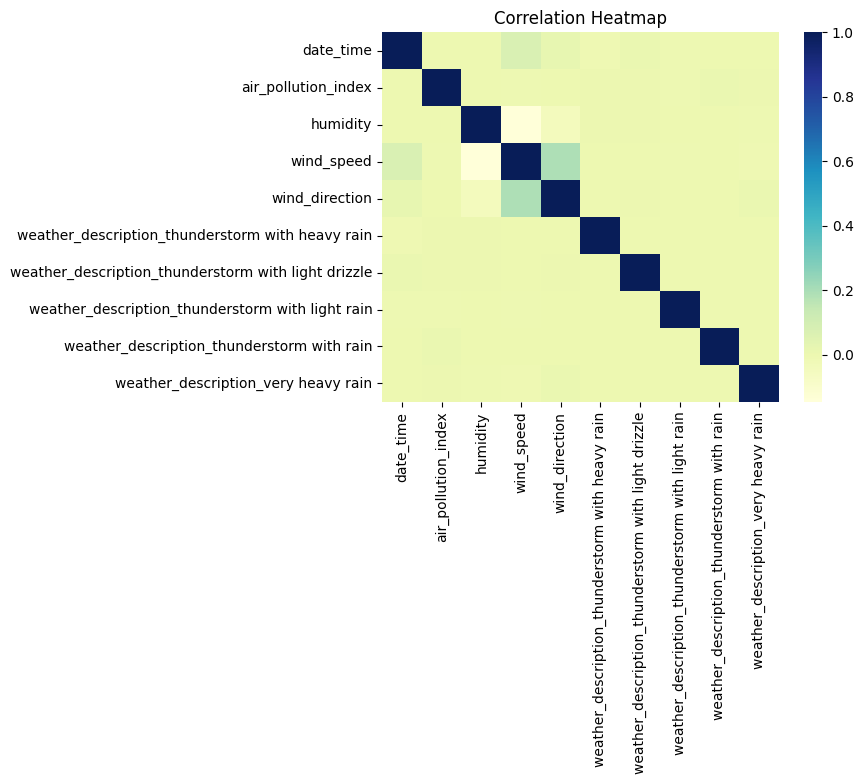

In [ ]:
import seaborn as sns

selected = ['date_time','air_pollution_index','humidity','wind_speed','wind_direction',
                         'weather_description_thunderstorm with heavy rain','weather_description_thunderstorm with light drizzle',
                         'weather_description_thunderstorm with light rain','weather_description_thunderstorm with rain',
                         'weather_description_very heavy rain']
corr_matrix = traffic[selected].corr()

sns.heatmap(corr_matrix,cmap='YlGnBu')
plt.title('Correlation Heatmap')


In [ ]:
traffic.dtypes

,0
date_time,int64
air_pollution_index,int64
humidity,int64
wind_speed,int64
wind_direction,int64
...,...
weather_description_thunderstorm with heavy rain,int64
weather_description_thunderstorm with light drizzle,int64
weather_description_thunderstorm with light rain,int64
weather_description_thunderstorm with rain,int64


In [ ]:

from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import numpy as np

# ... (your existing code)

# With Fine Tuning
# K-Nearest Neighbors (KNN)

# K-Nearest Neighbors (KNN) with Fine Tuning

# Fine-tune KNN by finding the optimal n_neighbors

X = traffic.drop('traffic_volume', axis=1)
y = traffic['traffic_volume']
y_categorized = y.apply(categorize_traffic)
X_train, X_test, y_train, y_test = train_test_split(X, y_categorized, test_size=0.25)

knn_tuned = KNeighborsClassifier()
param_grid = {'n_neighbors': np.arange(1, 25)} # Explore a range of neighbors
knn_gscv = GridSearchCV(knn_tuned, param_grid, cv=5) # 5-fold cross-validation
knn_gscv.fit(X_train, y_train)

best_knn = knn_gscv.best_estimator_
print(f"Best n_neighbors: {knn_gscv.best_params_['n_neighbors']}")

knn_tuned_pred = best_knn.predict(X_test)

print(classification_report(y_test, knn_tuned_pred))
print('\n')
print(confusion_matrix(y_test, knn_tuned_pred))

unique, counts = np.unique(knn_tuned_pred, return_counts=True)

# Create the bar chart
plt.figure(figsize=(8, 6))
plt.bar(unique, counts, color='mediumseagreen', edgecolor='black')
plt.xlabel('Traffic Volume Category (Predicted)')
plt.ylabel('Number of Predictions')
plt.title('KNN Fine-Tuned Predicted Traffic Volume')
plt.grid(axis='y')
plt.show()

#SVM

# Define the parameter grid for SVM
param_grid = {'C': [1, 10],
              'kernel': ['rbf']}

# Create a GridSearchCV object
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3, n_jobs=-1)

# Fit the grid search to the data
grid.fit(X_train, y_train)

# Print the best parameters and best score
print(grid.best_params_)
print(grid.best_estimator_)

# Make predictions using the best model
grid_predictions = grid.predict(X_test)

# Evaluate the model
print(classification_report(y_test, grid_predictions))
print('\n')
print(confusion_matrix(y_test, grid_predictions))


X = traffic.drop('traffic_volume', axis=1)
y = traffic['traffic_volume']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

predictions = dtree.predict(X_test)

print(classification_report(y_test,predictions))
print('\n')
print(confusion_matrix(y_test,predictions))

y_train.value_counts()
rfc_pred = rfc.predict(X_train)

print(classification_report(y_train, rfc_pred))
print('\n')
print(confusion_matrix(y_train, rfc_pred))

selected = ['date_time','air_pollution_index','humidity','wind_speed','wind_direction',
                         'weather_description_thunderstorm with heavy rain','weather_description_thunderstorm with light drizzle',
                         'weather_description_thunderstorm with light rain','weather_description_thunderstorm with rain',
                         'weather_description_very heavy rain']
corr_matrix = traffic[selected].corr()

sns.heatmap(corr_matrix,cmap='YlGnBu')
plt.title('Correlation Heatmap')
plt.show()
